# Pan Card Tampering Detection

# Subbarayudu Endluri
# Registration No :229X1A3234
#College :G.Pulla Reddy Engineering College,Kurnool
#email:subbarayuduendluri1230@gmail.com



Installing opencv,pillow and Streamlit


In [ ]:
!pip install opencv-python pillow streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00


Importing libraries

In [ ]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files


Uploading Image

In [ ]:

# Upload images
uploaded = files.upload()

Ensuring,loading and converting the image

In [ ]:
# Ensure two files are uploaded
if len(uploaded) < 2:
    print("❌ Please upload BOTH the original and tampered PAN card images.")
else:
    # Load and convert images
    original = cv2.imdecode(np.frombuffer(uploaded[list(uploaded.keys())[0]], np.uint8), cv2.IMREAD_COLOR)
    tampered = cv2.imdecode(np.frombuffer(uploaded[list(uploaded.keys())[1]], np.uint8), cv2.IMREAD_COLOR)

    # Convert to grayscale
    original_gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    tampered_gray = cv2.cvtColor(tampered, cv2.COLOR_BGR2GRAY)

Resizing the Image

In [ ]:
   # Resize if dimensions don't match
if original_gray.shape != tampered_gray.shape:
    tampered_gray = cv2.resize(tampered_gray, (original_gray.shape[1], original_gray.shape[0]))


Calculating and Printing SSIM

In [ ]:
    # Calculate SSIM
    (score, diff) = ssim(original_gray, tampered_gray, full=True)
    diff = (diff * 255).astype("uint8")

    # Display Results
    print(f"🔎 SSIM Score: {score:.4f} (Closer to 1 = More Similar)")

🔎 SSIM Score: 0.3633 (Closer to 1 = More Similar)


Visualising the images

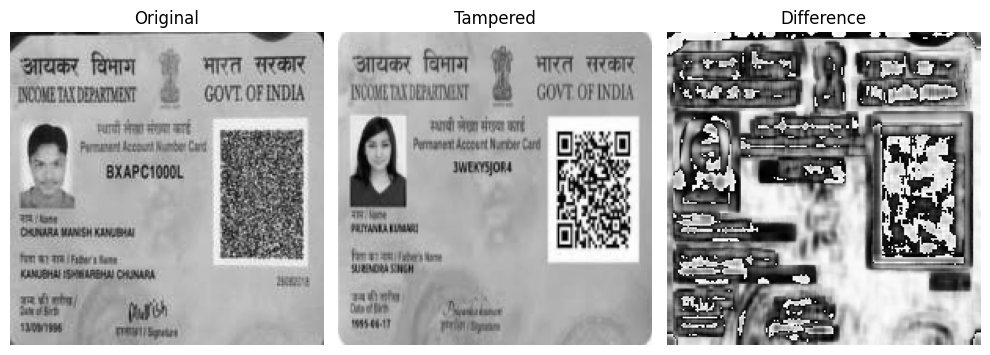

In [ ]:
    # Visualizing Original, Tampered, and Difference Images
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original_gray, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(tampered_gray, cmap='gray')
    plt.title("Tampered")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(diff, cmap='gray')
    plt.title("Difference")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Converting Original to GrayScale

In [ ]:
original_cv2 = cv2.cvtColor(np.array(original), cv2.COLOR_RGB2BGR)
tampered_cv2 = cv2.cvtColor(np.array(tampered), cv2.COLOR_RGB2BGR)

# Convert to grayscale
original_gray = cv2.cvtColor(original_cv2, cv2.COLOR_BGR2GRAY)
tampered_gray = cv2.cvtColor(tampered_cv2, cv2.COLOR_BGR2GRAY)


Displaying the images by Matplotlib Library

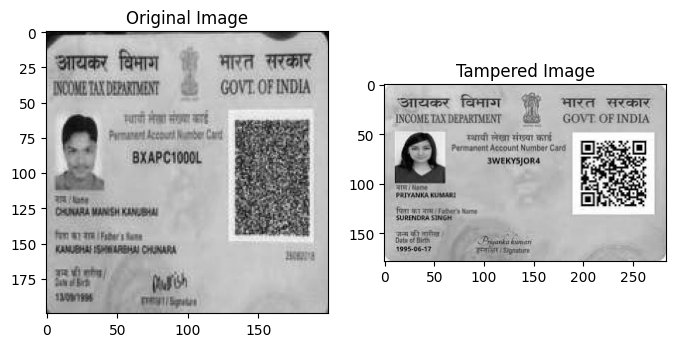

In [ ]:
# Display the images
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original_gray, cmap='gray')
plt.title("Original Image")
plt.subplot(1, 2, 2)
plt.imshow(tampered_gray, cmap='gray')
plt.title("Tampered Image")
plt.show()

Installing Stramlit Pyngrok

In [ ]:
!pip install streamlit pyngrok

creating and modifying an app.py

In [ ]:
%%writefile app.py
import streamlit as st
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from PIL import Image
import imutils

# Streamlit app title
st.title("🪪 PAN Card Tampering Detection")

# Upload original and tampered images
original = st.file_uploader("Upload Original PAN Card Image", type=["jpg", "jpeg", "png"])
tampered = st.file_uploader("Upload Tampered PAN Card Image", type=["jpg", "jpeg", "png"])

if original and tampered:
    # Load and convert images
    original_image = Image.open(original).convert('RGB')
    tampered_image = Image.open(tampered).convert('RGB')

    # Convert PIL images to OpenCV format
    original_cv = cv2.cvtColor(np.array(original_image), cv2.COLOR_RGB2BGR)
    tampered_cv = cv2.cvtColor(np.array(tampered_image), cv2.COLOR_RGB2BGR)

    # Convert images to grayscale for SSIM
    original_gray = cv2.cvtColor(original_cv, cv2.COLOR_BGR2GRAY)
    tampered_gray = cv2.cvtColor(tampered_cv, cv2.COLOR_BGR2GRAY)

    # Resize if dimensions don't match
    if original_gray.shape != tampered_gray.shape:
        tampered_gray = cv2.resize(tampered_gray, (original_gray.shape[1], original_gray.shape[0]))

    # SSIM calculation
    (score, diff) = ssim(original_gray, tampered_gray, full=True)
    diff = (diff * 255).astype("uint8")

    # Threshold and Contours
    thresh = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)[1]
    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    # Draw bounding boxes on both images
    for c in cnts:
        (x, y, w, h) = cv2.boundingRect(c)
        cv2.rectangle(original_cv, (x, y), (x + w, y + h), (0, 0, 255), 2)
        cv2.rectangle(tampered_cv, (x, y), (x + w, y + h), (0, 0, 255), 2)

    # Display uploaded images
    st.image(original_image, caption="🟩 Original PAN Card", use_column_width=True)
    st.image(tampered_image, caption="🟧 Tampered PAN Card", use_column_width=True)

    # Display SSIM score
    st.info(f"🔎 **SSIM Score:** {score:.4f} (Closer to 1 = More Similar)")

    # Display difference and contours
    st.image(diff, caption="🟥 Difference (Highlighting Tampered Areas)", use_column_width=True)
    st.image(original_cv, caption="🔎 Original PAN Card with Contours", use_column_width=True)
    st.image(tampered_cv, caption="🔎 Tampered PAN Card with Contours", use_column_width=True)

    # Optionally provide a conclusion
    if score > 0.9:
        st.success("✅ The images are highly similar — likely untampered.")
    elif score > 0.7:
        st.warning("⚠️ The images show some differences — possible minor tampering.")
    else:
        st.error("❌ Significant differences detected — potential tampering identified.")


Overwriting app.py


creating a password

In [ ]:
!curl https://loca.lt/mytunnelpassword

34.87.186.191

Running the application

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.186.191:8501

⠴⠦your url is: https://pretty-candles-win.loca.lt
2025-03-21 15:11:04.904 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `use_container_width` parameter instead.
2025-03-21 15:11:04.906 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `use_container_width` parameter instead.
2025-03-21 15:11:04.908 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `use_container_width` parameter instead.
2025-03-21 15:11:04.910 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `use_container_width` parameter instead.
2025-03-21 15:11:04.912 The `use_column_width` parameter h